In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['math score'], kde=True, ax=axes[0], color='steelblue')
sns.histplot(df['reading score'], kde=True, ax=axes[1], color='seagreen')
sns.histplot(df['writing score'], kde=True, ax=axes[2], color='indianred')
axes[0].set_title('Math Score Distribution')
axes[1].set_title('Reading Score Distribution')
axes[2].set_title('Writing Score Distribution')
plt.tight_layout()
plt.show()

In [4]:
df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [5]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [6]:
df.groupby('gender')[['math score', 'reading score', 'writing score']].mean()

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='parental level of education', y='math score', 
            order=['some high school', 'high school', 'some college', 
                   "associate's degree", "bachelor's degree", "master's degree"])
plt.xticks(rotation=30, ha='right')
plt.title('Math Score by Parental Education Level')
plt.tight_layout()
plt.show()

sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), 
            annot=True, cmap='Blues')
plt.title('Correlation Between Subject Scores')
plt.show()

In [9]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)
df['pass_fail'] = df['average_score'].apply(lambda x: 1 if x >= 60 else 0)
df['pass_fail'].value_counts()

pass_fail
1    715
0    285
Name: count, dtype: int64

from sklearn.preprocessing import LabelEncoder

df_model = df.copy()
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

le = LabelEncoder()
for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
X = df_model[features]
y = df_model['pass_fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.67
[[ 14  48]
 [ 18 120]]
              precision    recall  f1-score   support

           0       0.44      0.23      0.30        62
           1       0.71      0.87      0.78       138

    accuracy                           0.67       200
   macro avg       0.58      0.55      0.54       200
weighted avg       0.63      0.67      0.63       200



In [12]:
importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0]
})
importance = importance.sort_values('coefficient', ascending=False)
print(importance)

                       feature  coefficient
3                        lunch     1.211383
1               race/ethnicity     0.283869
2  parental level of education    -0.048226
0                       gender    -0.537861
4      test preparation course    -1.180306


Decision Tree Accuracy: 0.66


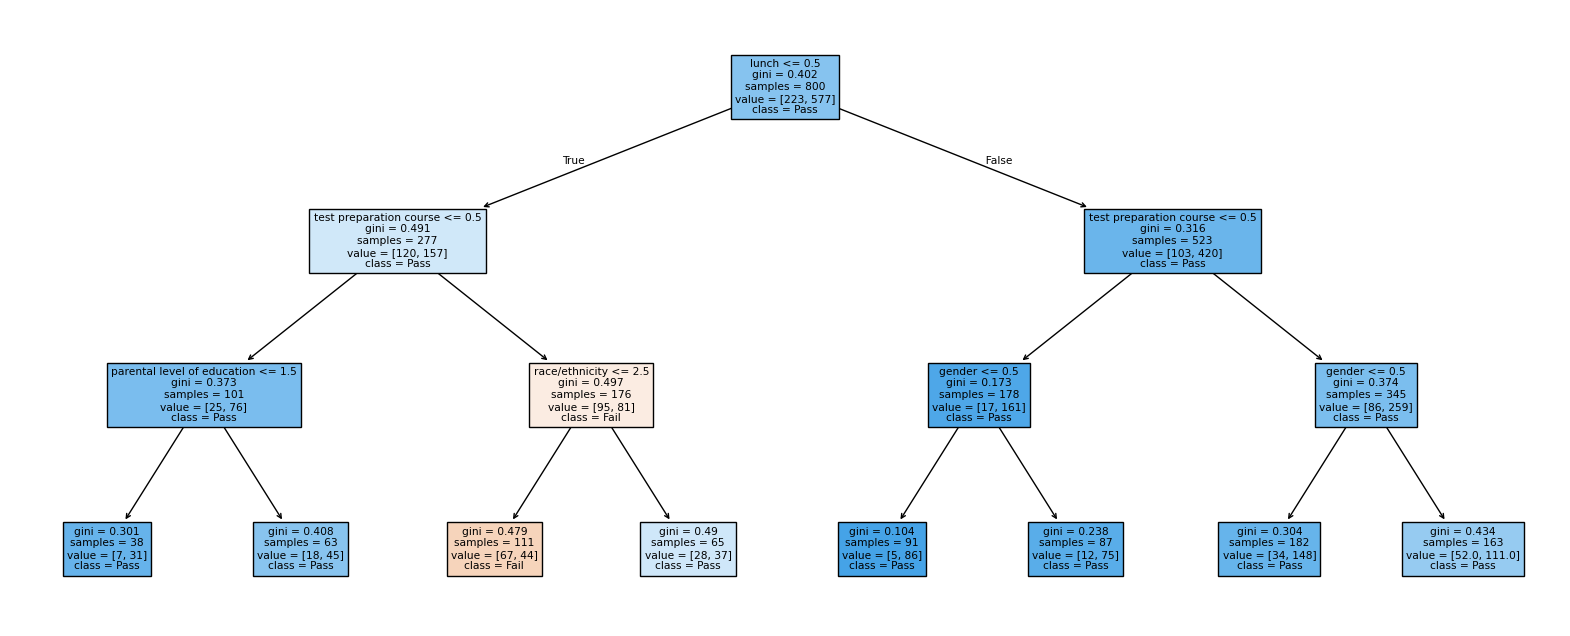

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

plt.figure(figsize=(20, 8))
plot_tree(tree_model, feature_names=features, class_names=['Fail', 'Pass'], filled=True)
plt.show()